
# Linear Dynamical Systems (LDS) in Python — Minimal Neuroscience-Focused Tutorial

This notebook walks through:
- **Part 1 (1D):** Numerical solution of $ \frac{dx}{dt} = a x $, behavior as $a$ varies, and an exercise with **complex** $a$.
- **Part 2 (2D):** Numerical solution of $ \frac{d\mathbf{x}}{dt} = A \mathbf{x}$, eigenvalues and stability, phase-plane trajectories, and flow fields. Includes an exercise to build **point attractor**, **line attractor**, and **unstable** systems.

> Tip: Keep time steps $\Delta t$ reasonably small for numerical stability when using explicit Euler.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
rng = np.random.default_rng(42)

# Matplotlib: single-figure style per plot (no seaborn), default colors only.
%matplotlib inline



## Part 1 — One-Dimensional Linear Dynamics

We study the scalar ODE
$
\frac{dx}{dt} = a x, \quad x(0) = x_0
$
The analytical solution is $x(t) = x_0 e^{a t} $. We'll:
1. Implement **explicit Euler** for numerical solution.
2. Compare numerical vs analytical trajectories for various  $a $.
3. Discuss how  $a $ shapes stability.


In [2]:

def euler_1d(a, x0=1.0, dt=0.01, T=5.0):
    """
    Explicit Euler integrator for dx/dt = a x.
    Returns t (N,), x_num (N,).
    """
    N = int(T/dt) + 1
    t = np.linspace(0.0, T, N)
    x = np.empty_like(t)
    x[0] = x0
    for k in range(N-1):
        x[k+1] = x[k] + a * x[k] * dt
    return t, x

def analytic_1d(a, x0=1.0, t=None):
    if t is None:
        raise ValueError("Provide time vector t")
    return x0 * np.exp(a * t)


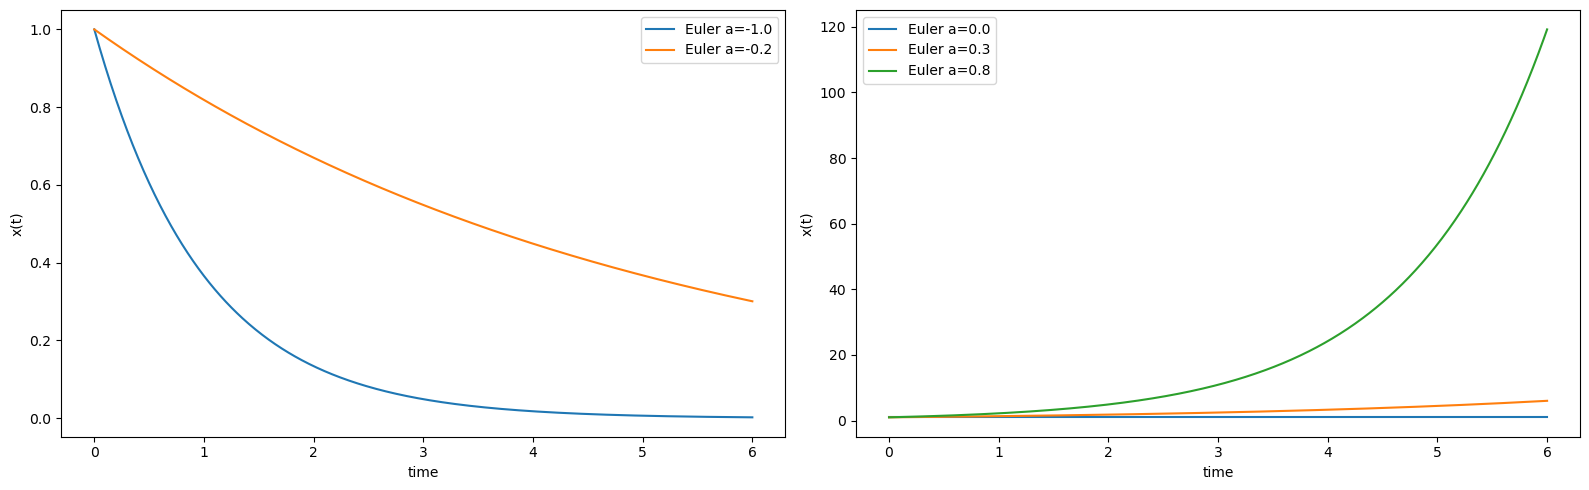

In [3]:
# --- Demo: numerical vs analytical for various a ---
a_list = [-1.0, -0.2, 0.0, 0.3, 0.8]
dt = 0.01
T = 6.0
x0 = 1.0

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

for a in a_list:
    t, x_num = euler_1d(a, x0=x0, dt=dt, T=T)
    x_ana = analytic_1d(a, x0=x0, t=t)
    i = 0 if a < 0 else 1
    axs[i].plot(t, x_num, label=f"Euler a={a}")
    # axs[i].plot(t, x_ana, '--', alpha=0.6)
    axs[i].set_xlabel("time")
    axs[i].set_ylabel("x(t)")

# ✅ add legends for both subplots
for ax in axs:
    ax.legend(loc="best")

plt.tight_layout()
plt.show()



### Exercise 1 — Complex  $a $
Let  $ a = \alpha + i \beta $.

1. Derive  $ x(t) = x_0 e^{\alpha t}(\cos \beta t + i \sin \beta t)  $.
2. Numerically simulate the **complex** dynamics using Euler updates on complex numbers when 1) a>0, b>0;2)a>0,b<0;3) a<0, b>0;4)a<0,b<0.
3. Plot **real** and **imaginary** parts, and discuss how  $\alpha $ (growth/decay rate) and  $\beta $ (oscillation frequency) shape the trajectory.

*(Hint: NumPy arrays support complex dtype. Try setting `x = np.zeros(N, dtype=complex)` and update with `x[k+1] = x[k] + a*x[k]*dt`.)*


In [4]:
import numpy as np
import matplotlib.pyplot as plt
## we need to slightly modity the euler solver for complex values
def euler_complex(a, x0=1+0j, dt=0.01, T=10.0):
    """Euler integration for dx/dt = a x, complex a."""
    N = int(T/dt) + 1
    t = np.linspace(0, T, N)
    x = np.zeros(N, dtype=complex)
    x[0] = x0
    for k in range(N-1):
        x[k+1] = x[k] + a * x[k] * dt
    return t, x

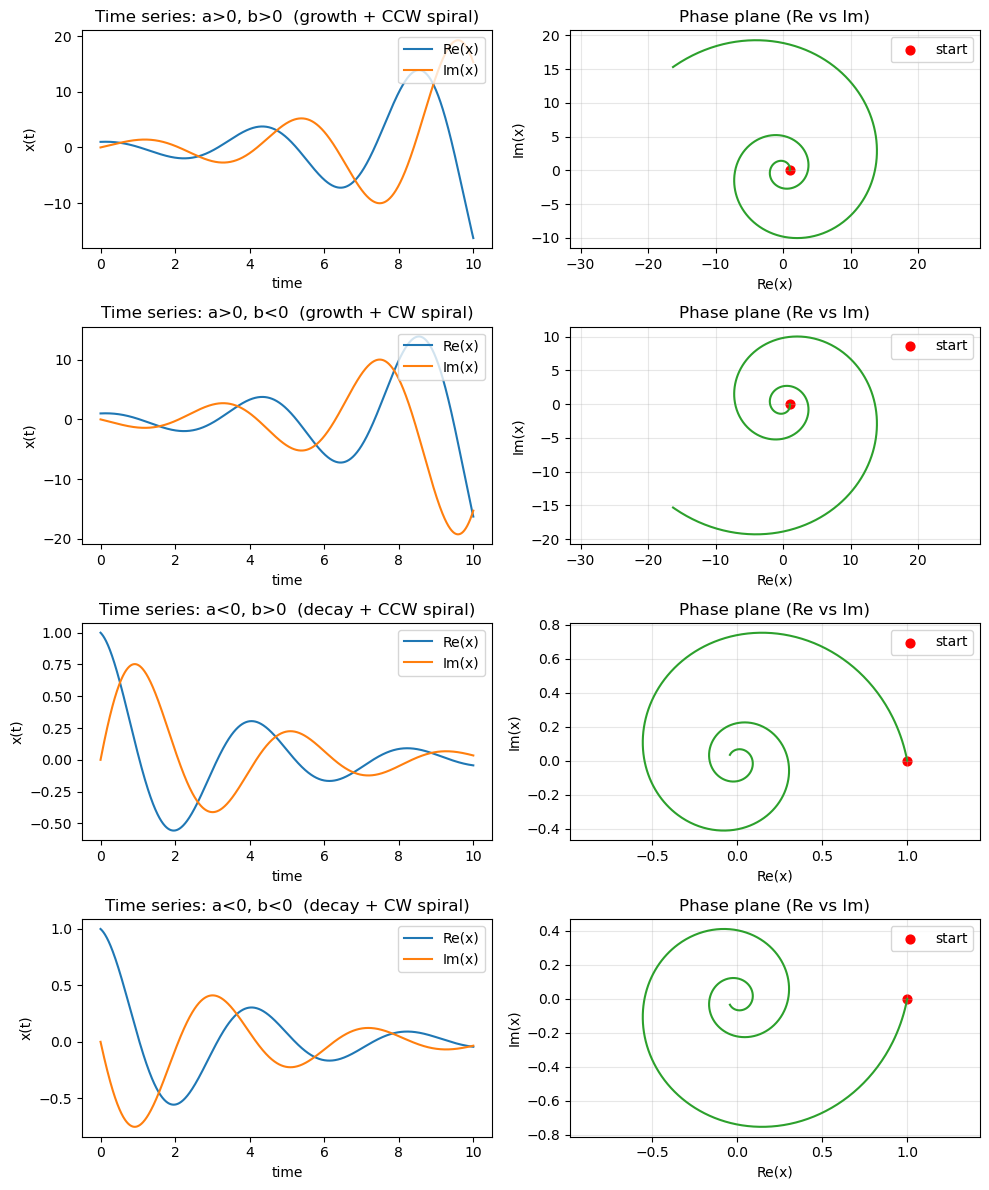

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Four parameter sets
# fill the value here
params = [
    (0.3 + 1.5j,  "a>0, b>0  (growth + CCW spiral)"),
    (0.3 - 1.5j,  "a>0, b<0  (growth + CW spiral)"),
    (-0.3 + 1.5j, "a<0, b>0  (decay + CCW spiral)"),
    (-0.3 - 1.5j, "a<0, b<0  (decay + CW spiral)")
]
fig, axs = plt.subplots(4, 2, figsize=(10, 12))
axs = axs.reshape(4, 2)

for i, (a, title) in enumerate(params):
    # solve the dynamical system with euler_complex function
    t, x = euler_complex(a, x0=1+0j, dt=0.01, T=10.0) 
    # ---- Time series plot ----
    axs[i, 0].plot(t, x.real, label="Re(x)", color="C0")
    axs[i, 0].plot(t, x.imag, label="Im(x)", color="C1")
    axs[i, 0].set_title(f"Time series: {title}")
    axs[i, 0].set_xlabel("time")
    axs[i, 0].set_ylabel("x(t)")
    axs[i, 0].legend(loc="upper right")

    # ---- Phase plane (complex plane) ----
    axs[i, 1].plot(x.real, x.imag, color="C2", lw=1.5)
    axs[i, 1].scatter(x.real[0], x.imag[0], color="red", s=40, label="start")  # start point
    axs[i, 1].set_title("Phase plane (Re vs Im)")
    axs[i, 1].set_xlabel("Re(x)")
    axs[i, 1].set_ylabel("Im(x)")
    axs[i, 1].axis("equal")
    axs[i, 1].grid(True, alpha=0.3)
    axs[i, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()



### Exercise 2 — Effect of  $\alpha$ and $\beta$
Let  $ a = \alpha + i \beta $.

Varing the value of $\alpha$  and  $\beta$ and plot the real and imaginary parts
*(Hint: NumPy arrays support complex dtype. Try setting `x = np.zeros(N, dtype=complex)` and update with `x[k+1] = x[k] + a*x[k]*dt`.)*


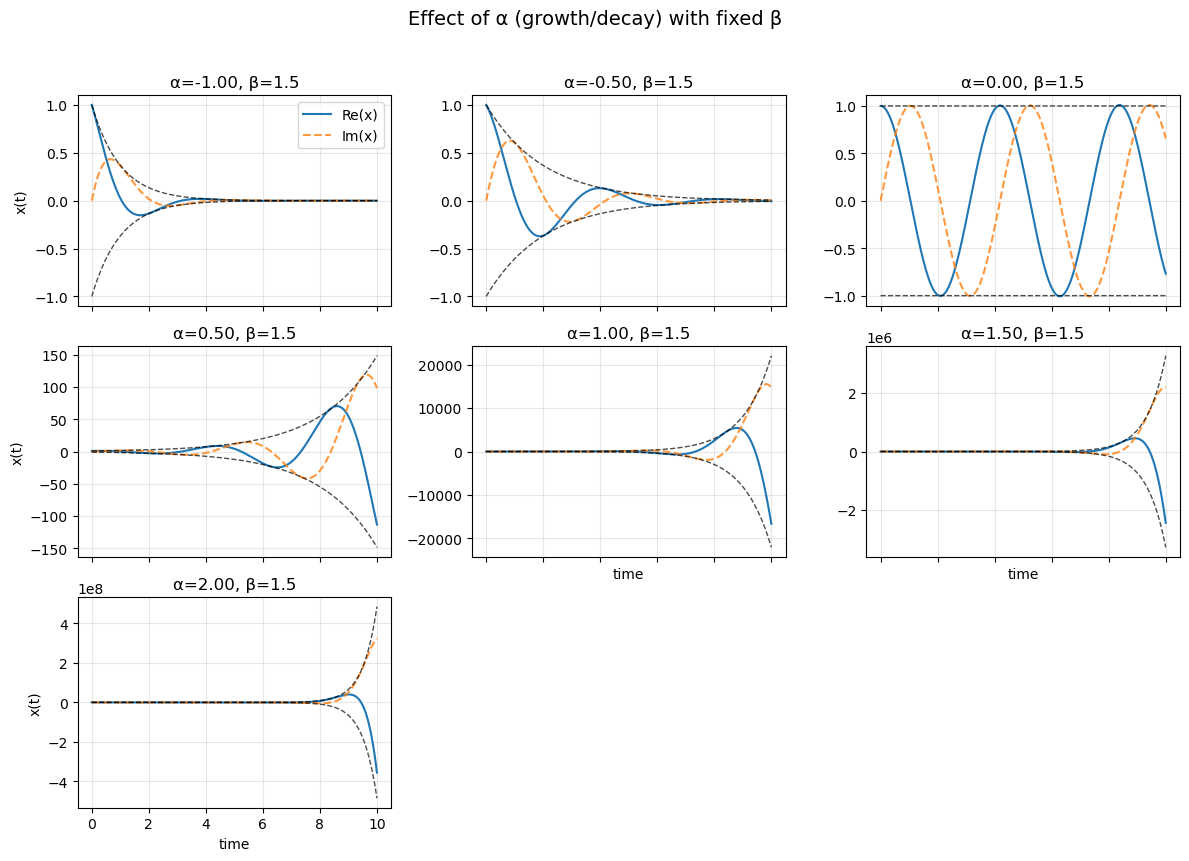

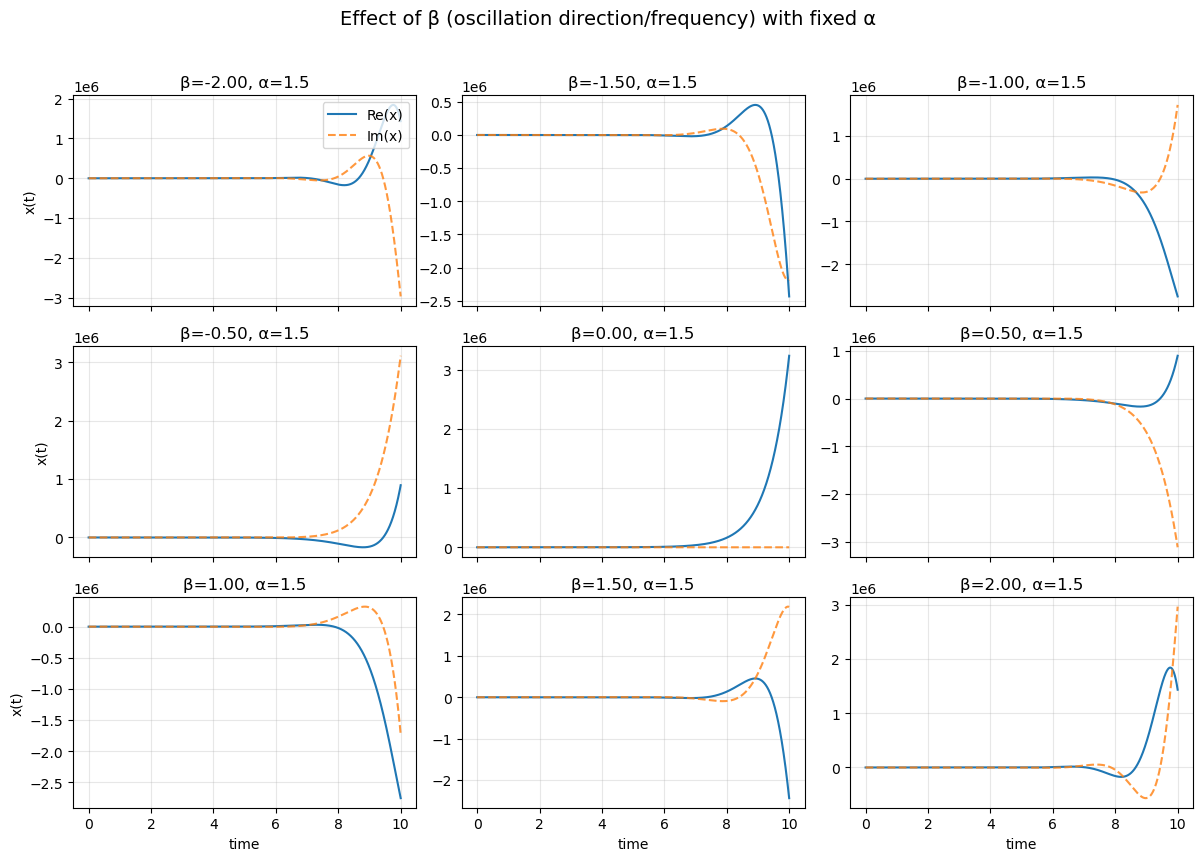

In [6]:
# =====================================================
# 1️⃣ Effect of α (fix β)
# =====================================================

## fill the value of beta and a list of values of alpha
beta = 1.5
alpha_values = [-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0]
ncols = 3
nrows = int(np.ceil(len(alpha_values) / ncols))
dt, T = 0.001, 10.0

fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.8*nrows), sharex=True)
axs = axs.ravel()

for i, alpha in enumerate(alpha_values):
    a = alpha + 1j * beta
    t, x = euler_complex(a, dt=dt, T=T)
    ax = axs[i]
    ax.plot(t, x.real, label="Re(x)", color="C0")
    ax.plot(t, x.imag, '--', label="Im(x)", color="C1", alpha=0.8)
    envelope = np.exp(alpha * t)
    ax.plot(t, envelope, 'k--', lw=1, alpha=0.7)
    ax.plot(t, -envelope, 'k--', lw=1, alpha=0.7)
    ax.set_title(f"α={alpha:.2f}, β={beta}")
    ax.grid(alpha=0.3)
    if i >= len(alpha_values) - ncols:
        ax.set_xlabel("time")
    if i % ncols == 0:
        ax.set_ylabel("x(t)")

# Remove unused axes if any
for j in range(len(alpha_values), len(axs)):
    fig.delaxes(axs[j])

axs[0].legend(loc="upper right")
fig.suptitle("Effect of α (growth/decay) with fixed β", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# =====================================================
# 2️⃣ Effect of β (fix α)
# =====================================================
## fill the value of alpha and a list of values of beta
alpha = 1.5
beta_values = [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0]
ncols = 3
nrows = int(np.ceil(len(beta_values) / ncols))
dt, T = 0.001, 10.0

fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.8*nrows), sharex=True)
axs = axs.ravel()

for i, beta in enumerate(beta_values):
    a = alpha + 1j * beta
    t, x = euler_complex(a, dt=dt, T=T)
    ax = axs[i]
    ax.plot(t, x.real, label="Re(x)", color="C0")
    ax.plot(t, x.imag, '--', label="Im(x)", color="C1", alpha=0.8)
    ax.set_title(f"β={beta:.2f}, α={alpha}")
    ax.grid(alpha=0.3)
    if i >= len(beta_values) - ncols:
        ax.set_xlabel("time")
    if i % ncols == 0:
        ax.set_ylabel("x(t)")

# Remove unused axes if any
for j in range(len(beta_values), len(axs)):
    fig.delaxes(axs[j])

axs[0].legend(loc="upper right")
fig.suptitle("Effect of β (oscillation direction/frequency) with fixed α", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



## Part 2 — Two-Dimensional Linear Dynamics

We extend to vector form:
$
\frac{d\mathbf{x}}{dt} = A \mathbf{x}, \quad \mathbf{x}=(x_1, x_2)^\top
$

We'll implement Euler integration, inspect eigenvalues  $\lambda_1,\lambda_2 $, and visualize trajectories and the flow field.


In [7]:

def euler_2d(A, x0, dt=0.01, T=8.0):
    """
    Explicit Euler for x' = A x in 2D.
    A: (2,2) array
    x0: (2,) initial condition
    Returns t (N,), X (N,2)
    """
    A = np.asarray(A, dtype=float)
    x = np.asarray(x0, dtype=float)
    N = int(T/dt) + 1
    t = np.linspace(0.0, T, N)
    X = np.empty((N, 2), dtype=float)
    X[0] = x
    for k in range(N-1):
        X[k+1] = X[k] + (A @ X[k]) * dt
    return t, X

def eig_info(A):
    """
    Return eigenvalues and eigenvectors (complex allowed).
    """
    vals, vecs = np.linalg.eig(A)
    return vals, vecs

def plot_phase_trajectories(A, initials, dt=0.01, T=8.0, ax=None, title=None):
    """
    Simulate several trajectories and plot x2 vs x1.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    for x0 in initials:
        t, X = euler_2d(A, x0, dt=dt, T=T)
        ax.plot(X[:,0], X[:,1])
        ax.plot([X[0,0]], [X[0,1]], marker='o')  # start
    ax.plot([0], [0], marker='x')  # fixed point at origin
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if title is not None:
        ax.set_title(title)
    # ax.axis('equal')
    return ax

def plot_flow_field(A, xlim=(-3,3), ylim=(-3,3), density=20, ax=None, title=None):
    """
    Plot vector field using a grid and quiver.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    x1 = np.linspace(xlim[0], xlim[1], density)
    x2 = np.linspace(ylim[0], ylim[1], density)
    X1, X2 = np.meshgrid(x1, x2)
    U = A[0,0]*X1 + A[0,1]*X2
    V = A[1,0]*X1 + A[1,1]*X2
    ax.quiver(X1, X2, U, V, angles='xy', scale_units='xy')
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if title is not None:
        ax.set_title(title)
    ax.axis('equal')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    return ax


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Stable node (real neg eigenvalues): eigenvalues = [-1.2 -0.5]


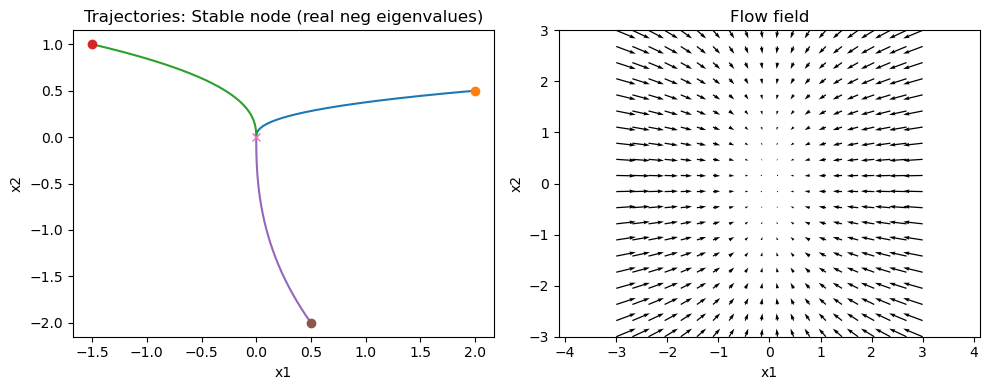

In [8]:

# --- Demo systems ---
A_list = {
    "Stable node (real neg eigenvalues)": np.array([[-1.2, 0.0],[0.0, -0.5]]),
}

initials = [np.array([2.0, 0.5]),
            np.array([-1.5, 1.0]),
            np.array([0.5, -2.0])]

for name, A in A_list.items():
    vals, _ = eig_info(A)
    print(f"{name}: eigenvalues = {vals}")
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    plot_phase_trajectories(A, initials, dt=0.01, T=12.0, ax=ax[0], title=f"Trajectories: {name}")
    plot_flow_field(A, xlim=(-3,3), ylim=(-3,3), density=20, ax=ax[1], title="Flow field")
    plt.tight_layout()
    plt.show()



### Exercise 2 — Build and diagnose three systems

Create three matrices  $A $ and, for each, compute eigenvalues, simulate trajectories, and plot the flow field.

1. **Point attractor (stable node)**  


2. **Line attractor (marginally stable along only one direction)**  

3. **Oscillatory stable system (complex eigenvalues with negative real parts, producing damped oscillations)**  

4. **Unstable system**  


**Tasks for each system:**
- Compute eigenvalues (and eigenvectors if helpful).
- Simulate several initial conditions.
- Plot phase-plane trajectories and the flow field.
- Label the stability type you observe from the plots and eigenvalues.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



Stable node (point attractor)
Eigenvalues: [-1.  -0.5]


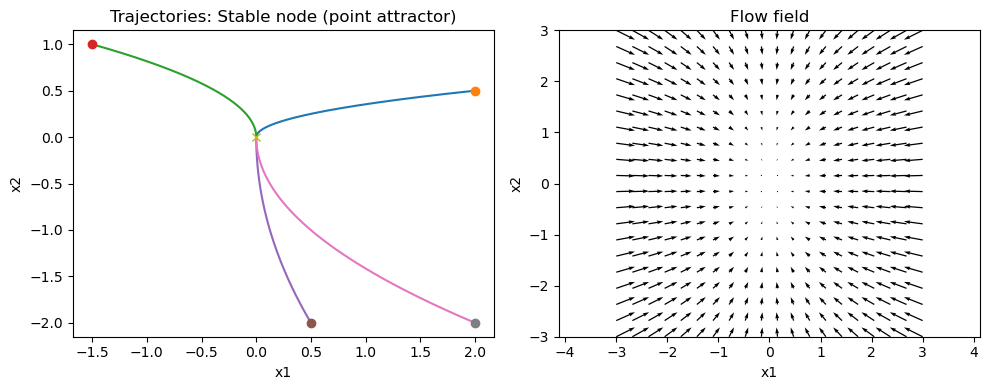


Line attractor (marginally stable)
Eigenvalues: [ 0.  -0.5]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


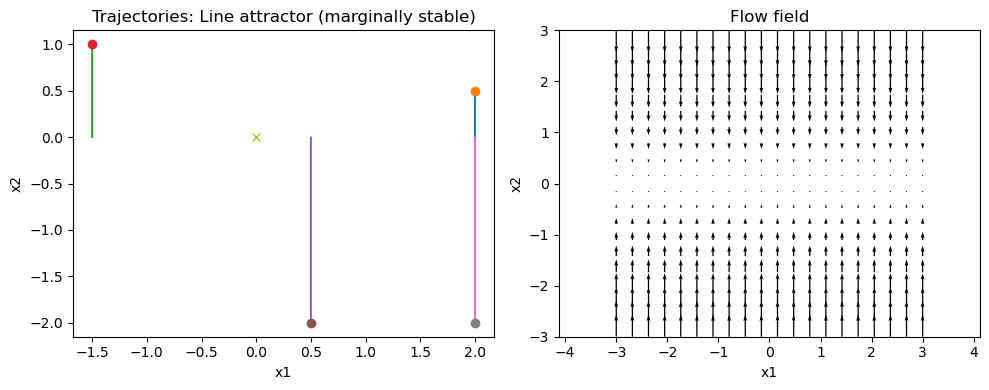


Unstable system (saddle point)
Eigenvalues: [ 0.8 -0.5]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


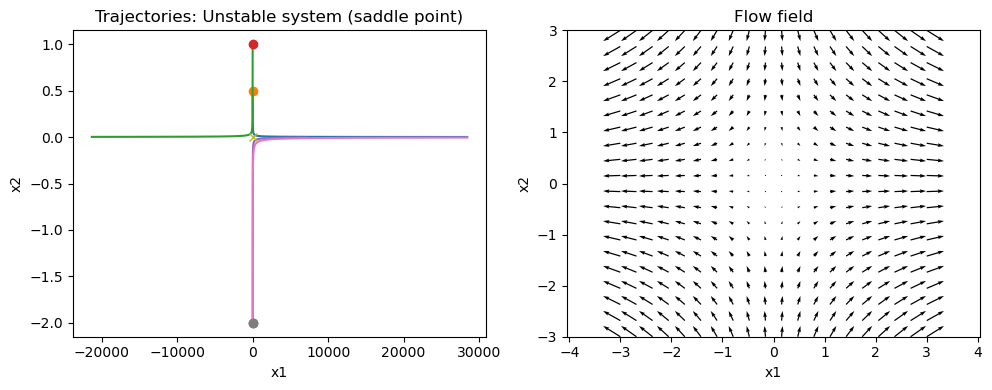


Oscillatory attractor (damped oscillation)
Eigenvalues: [-0.3+1.5j -0.3-1.5j]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


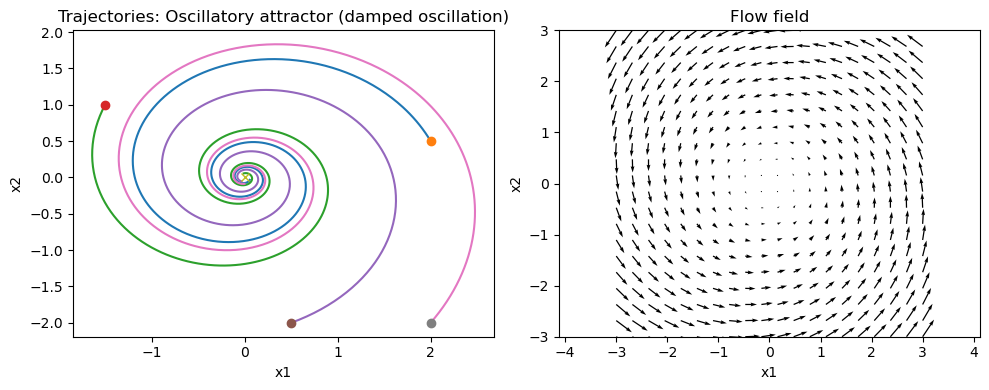

In [10]:


def matrix_from_eigenvalues(lambdas):
    """
    Construct a 2×2 real matrix given desired eigenvalues.

    Parameters
    ----------
    lambdas : list or np.ndarray
        Eigenvalues (length 2). 
        Can be real or complex conjugate pair.

    Returns
    -------
    A : np.ndarray
        2×2 real matrix with the given eigenvalues.
    """
    lambdas = np.asarray(lambdas)
    if np.iscomplex(lambdas).any():
        # Handle complex conjugate pair: a ± bi
        a = np.real(lambdas[0])
        b = np.imag(lambdas[0])
        A = np.array([[a, -b],
                      [b,  a]])
    else:
        # Real eigenvalues λ1, λ2
        λ1, λ2 = lambdas
        # Diagonalizable with real eigenvectors
        A = np.array([[λ1, 0.0],
                      [0.0, λ2]])
    return np.real_if_close(A)
# fill corresponding eigenvalues here
A_list = {
    # 1. Point attractor (stable node)
    "Stable node (point attractor)": matrix_from_eigenvalues([-1.0, -0.5]),

    # 2. Line attractor (marginally stable)
    "Line attractor (marginally stable)": matrix_from_eigenvalues([0.0, -0.5]),

    # 3. Unstable system (saddle)
    "Unstable system (saddle point)": matrix_from_eigenvalues([0.8, -0.5]),

    # 4. Oscillatory stable system (spiral sink)
    "Oscillatory attractor (damped oscillation)": matrix_from_eigenvalues([-0.3 + 1.5j, -0.3 - 1.5j]),
}

# === Plot results for all systems ===
initials = [np.array([2.0, 0.5]),
            np.array([-1.5, 1.0]),
            np.array([0.5, -2.0]),
            np.array([2.0, -2.0])]

for name, A in A_list.items():
    vals, vecs = eig_info(A)
    print(f"\n{name}")
    print(f"Eigenvalues: {np.round(vals,3)}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    plot_phase_trajectories(A, initials, dt=0.01, T=12.0, ax=ax[0],
                            title=f"Trajectories: {name}")
    plot_flow_field(A, xlim=(-3,3), ylim=(-3,3), density=20, ax=ax[1],
                    title="Flow field")
    plt.tight_layout()
    plt.show()


# Discrete Linear dynamical system
$ x_{k+1} = Fx_k$

## **Exercise 4 — Relationship Between Continuous and Discrete Linear Systems**

1. **Relationship between $F$ and $A$**  
   Derive mathematically how the discrete-time transition matrix $F$ is related to the continuous-time system matrix $A$.  
   Start from the continuous-time system  
   $$
   \frac{dx}{dt} = A\,x(t),
   $$
   and show how the solution $x(t+\Delta t)$ leads to a discrete-time update of the form  
   $$
   x_{k+1} = F\,x_k.
   $$  
   Express $F$ explicitly in terms of $A$ and the time step $\Delta t$.

Ans: $x(t+\Delta t)$ = $x(t)e^{A\Delta t}$. Thus $F = e^{A\Delta t}$


2. **Relationship between eigenvalues and eigenvectors of $F$ and $A$**  
   Show that if $v$ is an eigenvector of $A$ with eigenvalue $\lambda$, then it is also an eigenvector of $F$ with eigenvalue  
   $$
   \mu = e^{\lambda \Delta t}.
   $$  
   In other words, $A v = \lambda v \Rightarrow F v = e^{\lambda \Delta t} v.$

Ans: $F v = e^{A\Delta t} v = \sum\frac{(A\Delta t)^k}{k!} v = \sum\frac{(\lambda\Delta t)^k}{k!} v = e^{\lambda \Delta t} v$.

3. **Stability condition**  
   In a continuous-time system, stability depends on whether the real parts of the eigenvalues of $A$ are negative:  
   $$
   \text{Re}(\lambda) < 0.
   $$  
   In the discrete-time system, stability depends on whether the eigenvalues of $F$ lie **inside the unit circle** in the complex plane:  
   $$
   |\mu| < 1.
   $$  
   Discuss how these two stability criteria are consistent, given that $\mu = e^{\lambda \Delta t}$.

Ans: Suppose $\lambda = a + bi$, $|\mu| = |e^{\lambda \Delta t}| = |e^{a\Delta t}(\cos b\Delta t + i\sin b\Delta t)|$ = $e^{a\Delta t} $

Thus, $|\mu| < 1 \equiv a\Delta t < 0 \equiv \text{Re}(\lambda) < 0$ given $a = \text{Re}(\lambda)$

4. **Numerical simulation**  
    construct F for Point attractor, Line attractor Unstable system and Oscillatory attractor

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# === Discrete-time simulator ===
def discrete_2d(F, x0, dt=0.01, T=8.0):
    """
    Explicit discrete update x_{k+1} = F x_k in 2D.
    F: (2,2) array (transition matrix)
    x0: (2,) initial condition
    Returns t (N,), X (N,2)
    """
    F = np.asarray(F, dtype=float)
    x = np.asarray(x0, dtype=float)
    N = int(T/dt) + 1
    t = np.linspace(0.0, T, N)
    X = np.empty((N, 2), dtype=float)
    X[0] = x
    for k in range(N-1):
        X[k+1] = F @ X[k]
    return t, X

def eig_info(F):
    vals, vecs = np.linalg.eig(F)
    return vals, vecs

def plot_phase_trajectories(F, initials, dt=0.01, T=8.0, ax=None, title=None):
    """
    Simulate discrete trajectories and plot x2 vs x1.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    for x0 in initials:
        t, X = discrete_2d(F, x0, dt=dt, T=T)
        ax.plot(X[:,0], X[:,1], marker='.', ms=3)
        ax.plot([X[0,0]], [X[0,1]], 'o')  # start
    ax.plot([0],[0],'x')  # fixed point at origin
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if title: ax.set_title(title)
    return ax

def plot_flow_field(F, xlim=(-3,3), ylim=(-3,3), density=20, ax=None, title=None):
    """
    Plot discrete mapping vectors on grid (x -> Fx - x).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    x1 = np.linspace(*xlim, density)
    x2 = np.linspace(*ylim, density)
    X1, X2 = np.meshgrid(x1, x2)
    U = np.zeros_like(X1)
    V = np.zeros_like(X2)
    for i in range(density):
        for j in range(density):
            x = np.array([X1[i,j], X2[i,j]])
            Fx = F @ x
            diff = Fx - x
            U[i,j], V[i,j] = diff
    ax.quiver(X1, X2, U, V, angles='xy', scale_units='xy')
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    if title: ax.set_title(title)
    ax.axis('equal'); ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    return ax


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



Stable node (point attractor)
Eigenvalues: [0.95  0.975]


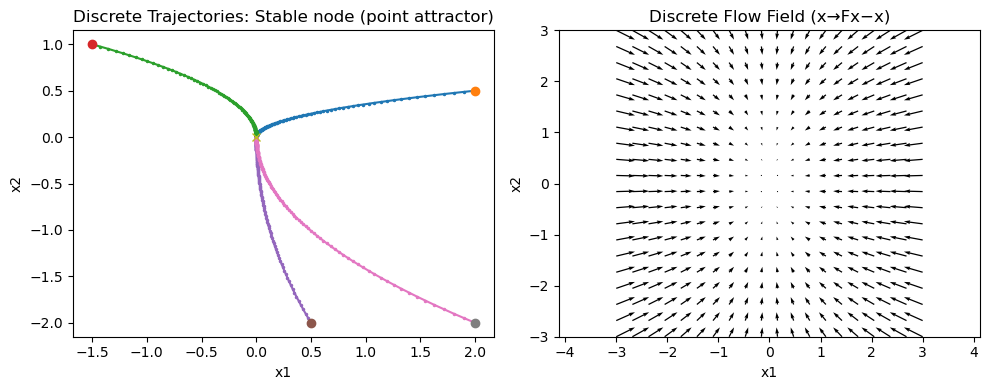


Line attractor (marginally stable)
Eigenvalues: [1.    0.975]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


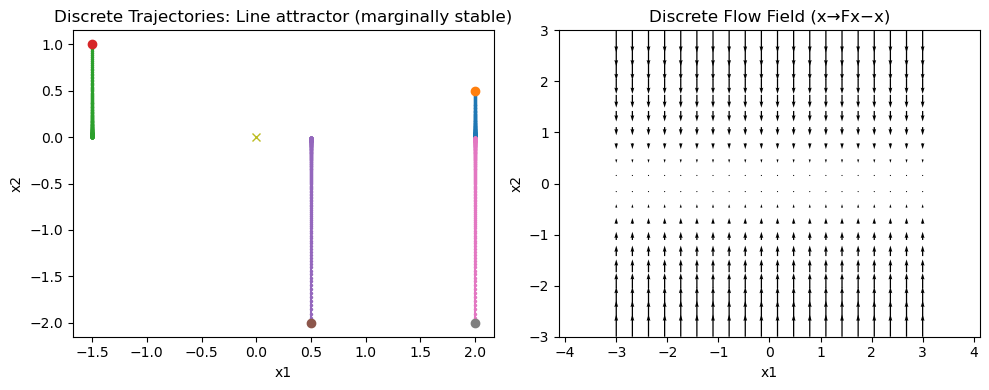


Unstable system (saddle point)
Eigenvalues: [1.04  0.975]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


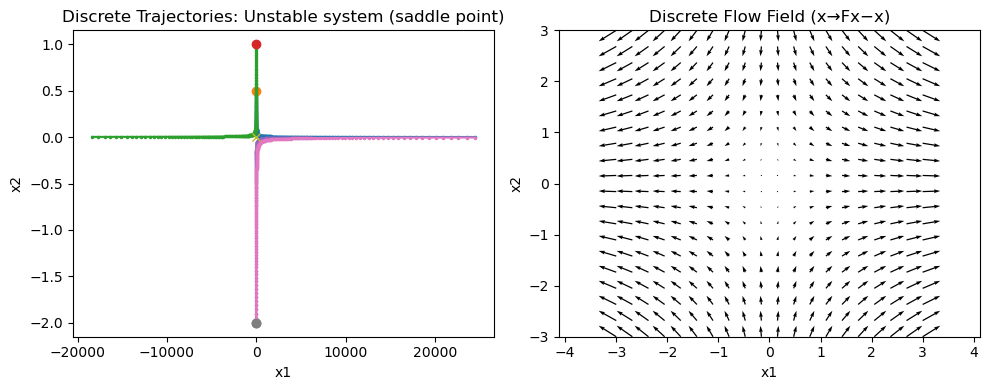


Oscillatory attractor (damped oscillation)
Eigenvalues: [0.985+0.075j 0.985-0.075j]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


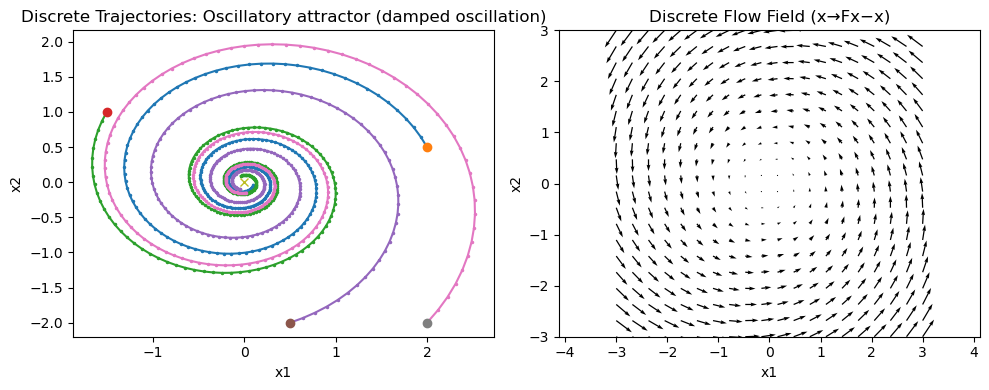

In [12]:
A_list = {
    "Stable node (point attractor)": matrix_from_eigenvalues([-1.0, -0.5]),
    "Line attractor (marginally stable)": matrix_from_eigenvalues([0.0, -0.5]),
    "Unstable system (saddle point)": matrix_from_eigenvalues([0.8, -0.5]),
    "Oscillatory attractor (damped oscillation)": matrix_from_eigenvalues([-0.3 + 1.5j, -0.3 - 1.5j]),
}

dt = 0.05
F_list = {name: np.eye(2) + A*dt for name, A in A_list.items()}

initials = [
    np.array([2.0, 0.5]),
    np.array([-1.5, 1.0]),
    np.array([0.5, -2.0]),
    np.array([2.0, -2.0])
]

for name, F in F_list.items():
    vals, _ = eig_info(F)
    print(f"\n{name}")
    print(f"Eigenvalues: {np.round(vals,3)}")

    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    plot_phase_trajectories(F, initials, dt=dt, T=12.0, ax=ax[0],
                            title=f"Discrete Trajectories: {name}")
    plot_flow_field(F, xlim=(-3,3), ylim=(-3,3), density=20, ax=ax[1],
                    title="Discrete Flow Field (x→Fx−x)")
    plt.tight_layout()
    plt.show()
